In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 12: Training a Multi-Timepoint Candidate Filter

**Objective:** Train the GT-like candidate filter on multiple timepoints from the same sample and test whether the filtered detector generalizes better to held-out timepoints.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- build one candidate-training table from multiple timepoints
- train a GT-like ranking model on a more diverse set of examples
- evaluate the filtered detector on held-out timepoints
- compare top-k filtering performance after multi-timepoint training
- determine whether broader training improves generalization

# 🧠 Background Theory

In Chapter 11, I found that a candidate-ranking model trained on a single reference frame (`t = 8`) did not generalize well across other timepoints.

That suggests the model learned frame-specific patterns rather than general rules for GT-like cell detections.

In this notebook, I will train the ranking model on multiple timepoints from the same sample so that it sees a wider range of cell appearances and spatial contexts before being evaluated on held-out timepoints.

# 🗺️ Chapter Roadmap

This notebook will proceed in six stages:

1. **Load the sample and detector utilities**
2. **Build a multi-timepoint candidate training table**
3. **Train a GT-like ranking model**
4. **Evaluate the detector on held-out timepoints**
5. **Compare top-k filtered detector performance**
6. **Visualize a held-out timepoint**

# 📚 New Vocabulary

## Multi-Timepoint Training
Training a model using examples collected from multiple timepoints instead of a single frame.

## Held-Out Timepoint
A timepoint that is not used for training and is only used for evaluation.

## Training Distribution
The range of examples the model sees during training. A broader training distribution can improve generalization.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 65.9 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Ground Truth

I will continue working with the same sample so I can isolate the effect of training on multiple timepoints.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

# Load image
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]   # shape: (T, Z, Y, X)

# Load graph
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("Total labeled nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
Total labeled nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [8]:
def evaluate_detector(gt_points, pred_points, match_radius=6):
    if len(pred_points) == 0:
        return {
            "num_gt": len(gt_points),
            "num_pred": 0,
            "gt_detected": 0,
            "gt_missed": len(gt_points),
            "pred_matched": 0,
            "pred_unmatched": 0,
            "gt_recall": 0.0,
            "pred_precision_like": np.nan,
        }

    dist = pairwise_distances_3d(gt_points, pred_points)

    min_dist_gt = dist.min(axis=1)
    min_dist_pred = dist.min(axis=0)

    gt_matched_mask = min_dist_gt <= match_radius
    pred_matched_mask = min_dist_pred <= match_radius

    gt_detected = gt_matched_mask.sum()
    gt_missed = len(gt_points) - gt_detected

    pred_matched = pred_matched_mask.sum()
    pred_unmatched = len(pred_points) - pred_matched

    return {
        "num_gt": len(gt_points),
        "num_pred": len(pred_points),
        "gt_detected": gt_detected,
        "gt_missed": gt_missed,
        "pred_matched": pred_matched,
        "pred_unmatched": pred_unmatched,
        "gt_recall": gt_detected / len(gt_points),
        "pred_precision_like": pred_matched / len(pred_points),
    }

In [9]:
def extract_candidate_features(frame_3d, detections_df, patch_radius=4):
    rows = []
    z_max, y_max, x_max = frame_3d.shape

    for _, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z].astype(np.float32)

        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1]

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        max_idx = np.unravel_index(np.argmax(patch), patch.shape)
        max_y_patch, max_x_patch = max_idx
        patch_center_y = y - y0
        patch_center_x = x - x0

        center_to_patch_max_dist = float(
            np.sqrt((max_y_patch - patch_center_y)**2 + (max_x_patch - patch_center_x)**2)
        )

        yy, xx = np.indices(patch.shape)
        patch_sum = patch.sum()

        if patch_sum > 0:
            com_y = float((yy * patch).sum() / patch_sum)
            com_x = float((xx * patch).sum() / patch_sum)
            patch_com_offset = float(
                np.sqrt((com_y - patch_center_y)**2 + (com_x - patch_center_x)**2)
            )
        else:
            patch_com_offset = np.nan

        border_margin = min(y, x, y_max - 1 - y, x_max - 1 - x)
        is_near_border = int(border_margin < patch_radius)

        z_vals_local = []
        for zz in [z - 1, z, z + 1]:
            if 0 <= zz < z_max:
                z_vals_local.append(float(frame_3d[zz, y, x]))

        z_center_intensity = float(frame_3d[z, y, x])
        z_support_mean = float(np.mean(z_vals_local))
        z_support_std = float(np.std(z_vals_local))
        z_support_min = float(np.min(z_vals_local))
        z_support_max = float(np.max(z_vals_local))

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": float(row["sigma"]),
            "nearest_gt_dist": float(row["nearest_gt_dist"]),
            "matched": bool(row["matched"]),
            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,
            "z_center_intensity": z_center_intensity,
            "z_support_mean": z_support_mean,
            "z_support_std": z_support_std,
            "z_support_min": z_support_min,
            "z_support_max": z_support_max,
        })

    return pd.DataFrame(rows)

# Step 2 — Define Training and Held-Out Timepoints

I will train the ranking model on several timepoints and reserve later timepoints for evaluation.

In [10]:
train_timepoints = [0, 8, 20, 40]
test_timepoints = [60, 80]

print("Train timepoints:", train_timepoints)
print("Test timepoints:", test_timepoints)

Train timepoints: [0, 8, 20, 40]
Test timepoints: [60, 80]


# Step 3 — Build a Multi-Timepoint Candidate Training Table

For each training timepoint, I will run LoG, label detections by GT proximity, extract candidate features, and append everything into one combined training table.

In [11]:
train_candidate_tables = []

for t in train_timepoints:
    frame_t = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points_t = gt_nodes_t[["z", "y", "x"]].to_numpy()

    blob_t = detect_blobs_log_3d_slicewise(frame_t)

    if len(blob_t) == 0 or len(gt_points_t) == 0:
        continue

    blob_points_t = blob_t[["z", "y", "x"]].to_numpy()
    dist_t = pairwise_distances_3d(gt_points_t, blob_points_t)

    blob_t["nearest_gt_dist"] = dist_t.min(axis=0)
    blob_t["matched"] = blob_t["nearest_gt_dist"] <= 6

    candidate_t = extract_candidate_features(frame_t, blob_t, patch_radius=4)
    candidate_t["t"] = t

    train_candidate_tables.append(candidate_t)

train_candidate_df = pd.concat(train_candidate_tables, ignore_index=True)

print("Combined training candidate rows:", len(train_candidate_df))
print(train_candidate_df["matched"].value_counts())
train_candidate_df.head()

Combined training candidate rows: 6268
matched
False    6152
True      116
Name: count, dtype: int64


,z,y,x,sigma,nearest_gt_dist,matched,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,z_center_intensity,z_support_mean,z_support_std,z_support_min,z_support_max,t
0,0,0,15,3.5,89.983332,False,1008.0,743.688904,1071.0,178.047287,264.311096,2.000000,1.686796,1,1008.0,807.5,200.5,607.0,1008.0,0
1,0,137,0,2.5,80.616376,False,972.0,641.177795,1044.0,182.555481,330.822205,1.000000,1.646079,1,972.0,1059.0,87.0,972.0,1146.0,0
2,0,129,12,3.5,78.025637,False,951.0,824.740723,995.0,86.869965,126.259277,2.236068,0.067501,0,951.0,875.5,75.5,800.0,951.0,0
3,0,189,0,3.5,57.227616,False,910.0,713.200012,920.0,110.239052,196.799988,1.000000,1.822663,1,910.0,748.0,162.0,586.0,910.0,0
4,0,105,14,3.5,78.000000,False,864.0,690.209900,864.0,97.600563,173.790100,1.000000,0.005306,0,864.0,898.0,34.0,864.0,932.0,0


# Step 4 — Train the Multi-Timepoint Ranking Model

Now I will train a GT-like ranking model on the combined candidate table built from multiple training timepoints.

In [12]:
feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "z_center_intensity",
    "z_support_mean",
    "z_support_std",
    "z_support_min",
    "z_support_max",
]

X_train_all = train_candidate_df[feature_cols]
y_train_all = train_candidate_df["matched"].astype(int)

clf_multi = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=8
)

clf_multi.fit(X_train_all, y_train_all)

print("Multi-timepoint ranking model trained.")

Multi-timepoint ranking model trained.


In [13]:
def evaluate_timepoint_with_ranker(
    image,
    nodes_df,
    t,
    clf,
    feature_cols,
    topk_values=(25, 50, 100),
    match_radius=6
):
    frame_3d = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

    blob_df = detect_blobs_log_3d_slicewise(frame_3d)

    if len(blob_df) == 0 or len(gt_points) == 0:
        return None, None, None

    blob_points = blob_df[["z", "y", "x"]].to_numpy()
    dist = pairwise_distances_3d(gt_points, blob_points)

    blob_df["nearest_gt_dist"] = dist.min(axis=0)
    blob_df["matched"] = blob_df["nearest_gt_dist"] <= match_radius

    candidate_df = extract_candidate_features(frame_3d, blob_df, patch_radius=4)
    candidate_df = candidate_df.copy()
    candidate_df["gt_like_score"] = clf.predict_proba(candidate_df[feature_cols])[:, 1]

    ranked_df = candidate_df.sort_values("gt_like_score", ascending=False)

    raw_eval = evaluate_detector(
        gt_points,
        candidate_df[["z", "y", "x"]].to_numpy(),
        match_radius=match_radius
    )

    rows = [{
        "t": t,
        "detector": "raw_log",
        "num_gt": len(gt_points),
        "num_pred": raw_eval["num_pred"],
        "gt_detected": raw_eval["gt_detected"],
        "gt_missed": raw_eval["gt_missed"],
        "pred_matched": raw_eval["pred_matched"],
        "pred_unmatched": raw_eval["pred_unmatched"],
        "gt_recall": raw_eval["gt_recall"],
        "pred_precision_like": raw_eval["pred_precision_like"],
        "match_rate_in_kept_set": candidate_df["matched"].mean()
    }]

    for k in topk_values:
        topk_df = ranked_df.head(k).copy()
        pred_points_k = topk_df[["z", "y", "x"]].to_numpy()

        result_k = evaluate_detector(gt_points, pred_points_k, match_radius=match_radius)

        rows.append({
            "t": t,
            "detector": f"top_{k}",
            "num_gt": len(gt_points),
            "num_pred": result_k["num_pred"],
            "gt_detected": result_k["gt_detected"],
            "gt_missed": result_k["gt_missed"],
            "pred_matched": result_k["pred_matched"],
            "pred_unmatched": result_k["pred_unmatched"],
            "gt_recall": result_k["gt_recall"],
            "pred_precision_like": result_k["pred_precision_like"],
            "match_rate_in_kept_set": topk_df["matched"].mean()
        })

    results_df = pd.DataFrame(rows)
    return results_df, ranked_df, gt_nodes_t

# Step 5 — Evaluate the Filtered Detector on Held-Out Timepoints

Now I will apply the multi-timepoint ranking model to timepoints that were not used during training.

In [14]:
heldout_results = []
heldout_ranked = {}
heldout_gt = {}

for t in test_timepoints:
    results_t, ranked_t, gt_nodes_t = evaluate_timepoint_with_ranker(
        image=image,
        nodes_df=nodes_df,
        t=t,
        clf=clf_multi,
        feature_cols=feature_cols,
        topk_values=(25, 50, 100),
        match_radius=6
    )

    if results_t is not None:
        heldout_results.append(results_t)
        heldout_ranked[t] = ranked_t
        heldout_gt[t] = gt_nodes_t

heldout_results_df = pd.concat(heldout_results, ignore_index=True)
heldout_results_df

,t,detector,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,match_rate_in_kept_set
0,60,raw_log,9,1844,8,1,25,1819,0.888889,0.013557,0.013557
1,60,top_25,9,25,0,9,0,25,0.000000,0.000000,0.000000
2,60,top_50,9,50,0,9,0,50,0.000000,0.000000,0.000000
3,60,top_100,9,100,0,9,0,100,0.000000,0.000000,0.000000
4,80,raw_log,6,1971,4,2,15,1956,0.666667,0.007610,0.007610
5,80,top_25,6,25,0,6,0,25,0.000000,0.000000,0.000000
6,80,top_50,6,50,0,6,0,50,0.000000,0.000000,0.000000
7,80,top_100,6,100,0,6,0,100,0.000000,0.000000,0.000000


In [15]:
heldout_summary = heldout_results_df.pivot_table(
    index="t",
    columns="detector",
    values=["gt_recall", "pred_precision_like", "num_pred"],
    aggfunc="first"
)

heldout_summary

gt_recall                       num_pred                        \
detector   raw_log top_100 top_25 top_50  raw_log top_100 top_25 top_50   
t                                                                         
60        0.888889     0.0    0.0    0.0     1844     100     25     50   
80        0.666667     0.0    0.0    0.0     1971     100     25     50   

         pred_precision_like                        
detector             raw_log top_100 top_25 top_50  
t                                                   
60                  0.013557     0.0    0.0    0.0  
80                  0.007610     0.0    0.0    0.0

In [16]:
heldout_avg_df = (
    heldout_results_df
    .groupby("detector")[["gt_recall", "pred_precision_like", "num_pred"]]
    .mean()
    .sort_values("gt_recall", ascending=False)
)

heldout_avg_df

,gt_recall,pred_precision_like,num_pred
detector,,,
raw_log,0.777778,0.010584,1907.5
top_100,0.000000,0.000000,100.0
top_25,0.000000,0.000000,25.0
top_50,0.000000,0.000000,50.0


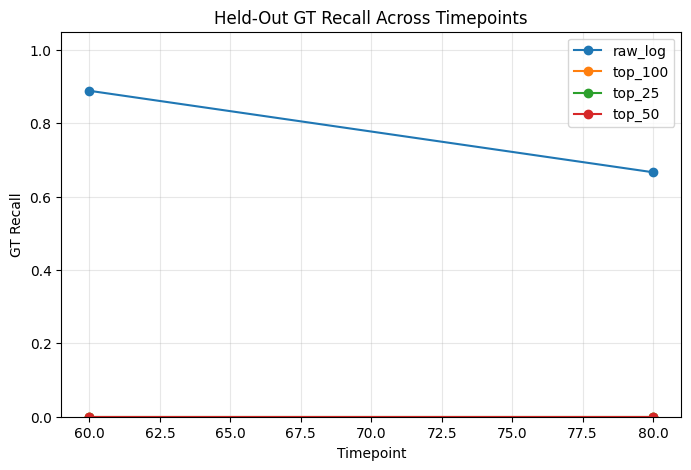

In [17]:
plt.figure(figsize=(8, 5))

for detector_name, group in heldout_results_df.groupby("detector"):
    plt.plot(group["t"], group["gt_recall"], marker="o", label=detector_name)

plt.title("Held-Out GT Recall Across Timepoints")
plt.xlabel("Timepoint")
plt.ylabel("GT Recall")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

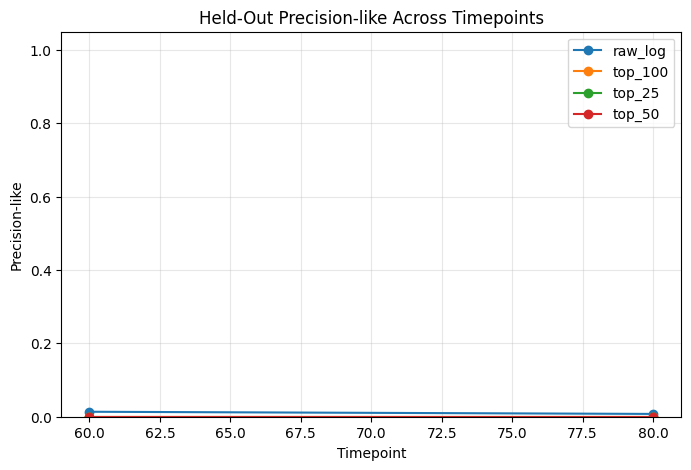

In [18]:
plt.figure(figsize=(8, 5))

for detector_name, group in heldout_results_df.groupby("detector"):
    plt.plot(group["t"], group["pred_precision_like"], marker="o", label=detector_name)

plt.title("Held-Out Precision-like Across Timepoints")
plt.xlabel("Timepoint")
plt.ylabel("Precision-like")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 6 — Visualize a Held-Out Timepoint

I will overlay filtered predictions on one held-out timepoint to see whether multi-timepoint training produces a more stable filtered detector.

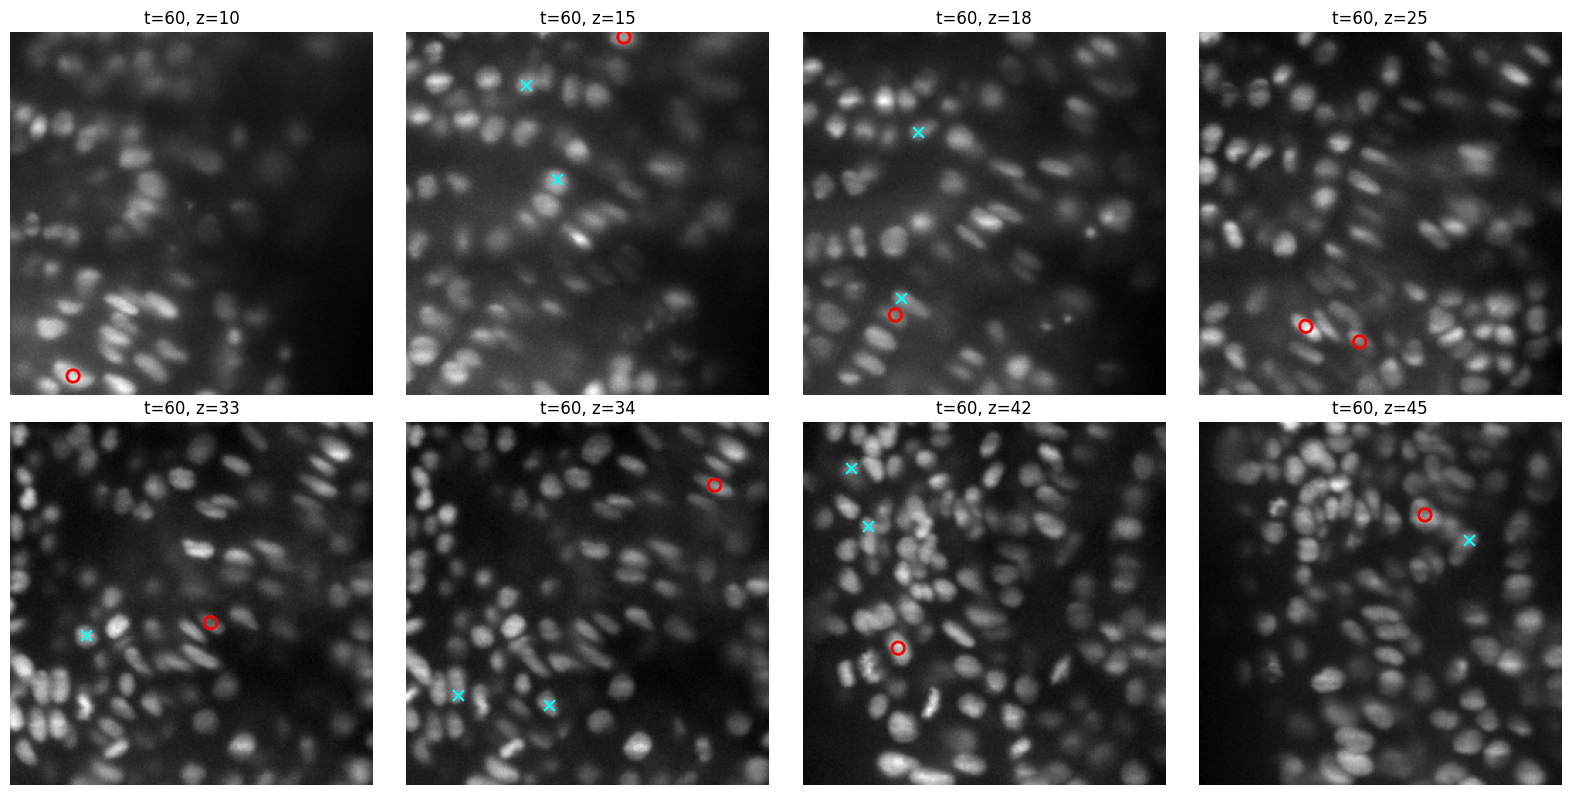

In [19]:
t_vis = 60
top_k_vis = 50

ranked_vis = heldout_ranked[t_vis]
gt_vis = heldout_gt[t_vis]
frame_vis = image[t_vis]

top_vis_df = ranked_vis.head(top_k_vis).copy()
gt_z_slices = sorted(gt_vis["z"].unique())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, gt_z_slices[:8]):
    slice_img = frame_vis[z]
    gt_slice = gt_vis[gt_vis["z"] == z]
    pred_slice = top_vis_df[top_vis_df["z"] == z]

    ax.imshow(slice_img, cmap="gray")

    # GT = red circles
    ax.scatter(gt_slice["x"], gt_slice["y"],
               facecolors="none", edgecolors="red", s=80, linewidths=2)

    # filtered predictions = cyan x
    ax.scatter(pred_slice["x"], pred_slice["y"],
               c="cyan", marker="x", s=60)

    ax.set_title(f"t={t_vis}, z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
importance_df_multi = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf_multi.feature_importances_
}).sort_values("importance", ascending=False)

importance_df_multi

,feature,importance
7,patch_com_offset,0.156345
13,z_support_max,0.119295
2,patch_mean,0.090597
4,patch_std,0.084121
11,z_support_std,0.079030
10,z_support_mean,0.075944
5,local_contrast,0.074177
12,z_support_min,0.070895
9,z_center_intensity,0.058457
1,center_intensity,0.058095


# 📊 Results

I trained a GT-like candidate-ranking model on multiple timepoints from sample `44b6_12dfb391` and evaluated it on held-out timepoints `t = 60` and `t = 80`.

## Main result
The multi-timepoint ranking model did **not** improve held-out filtered detector performance.

### Held-out raw LoG performance
- `t = 60`: GT recall = 0.8889
- `t = 80`: GT recall = 0.6667
- average raw recall ≈ 0.7778

### Held-out filtered detector performance
For `top_25`, `top_50`, and `top_100`, held-out GT recall was **0.0** on both test timepoints.

This means the ranking model selected candidates that did not align with GT centroids on the held-out frames.

# 🔍 Analysis

This experiment showed that simply training the candidate filter on more timepoints was not enough to produce a robust held-out detector.

## Main findings

### 1. Raw LoG remains the strongest held-out detector
Although raw LoG produces many false positives, it still recovers a large fraction of GT centroids on held-out timepoints.

### 2. The filtered detector completely failed on held-out frames
The ranking model did not preserve any GT detections in the top-k filtered candidate sets.

### 3. The current candidate labels are likely too weak
Candidates were labeled positive if they were within a radius of a GT centroid and negative otherwise. Because the ground-truth graph is sparse, unmatched detections are not guaranteed to be biologically false. This likely makes the ranking task noisy.

### 4. The current feature/ranking setup is not yet learning general “cellness”
The model appears to rank candidates using frame-specific appearance cues rather than stable indicators of true nucleus centroids.

# 📝 What I Learned

Today I learned that:

- expanding training from one timepoint to several timepoints did not solve the detector generalization problem
- raw LoG remains a strong high-recall baseline even when learned filtering fails
- the current GT-proximity labeling strategy is probably too weak for training a robust candidate filter
- the next improvement should focus on the ranking target or filtering strategy, not just adding more training timepoints